In [1]:
import seaborn as sns

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")


In [2]:
#parameters
db = "enamine10k_batch.sqlite"
TITLE = "Enamine10k"

In [3]:
# Parameters
db = "mcl1_mmpbsa_gb_shuffled.sqlite"
TITLE = "MCL1-MMPBSA"


In [4]:
data, top_k = load_data(f"results/{db}", k_ratio=0.01)
K = len(top_k)
data.head()

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,Iteration,cluster,output_file_path,is_validation_result,...,output_file,n_clusters,simulator,bandit_confidence,job_id,Embedding Model,Surrogate,Scoring,is_top_k,is_top_k_cum
0,1,1,O=C(OCc1cccc2cccnc12)c1[nH]c2c(Br)cccc2c1CCCO,-41.948575,-41.948575,0.702393,0,0,None,0,...,mcl1_mmpbsa_gb_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
1,2,1,C=CC[C@](C)(CC)COC(=O)CCc1c[nH]c2cc(Cl)ccc12,-32.127669,-41.948575,2.004909,1,0,None,0,...,mcl1_mmpbsa_gb_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
2,3,1,O=C(O)c1[nH]c2ccc(Br)cc2c1CCO,-26.643830,-42.310369,0.046878,2,0,None,0,...,mcl1_mmpbsa_gb_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
3,4,1,O=C(OCc1cccc(F)c1Br)c1[nH]c2c(Br)cccc2c1CCCO,-41.867471,-41.311815,1.361735,3,0,None,0,...,mcl1_mmpbsa_gb_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
4,5,1,O=C(OCc1c(Br)cncc1Br)c1[nH]c2c(Br)cccc2c1CCCO,-42.256509,-42.008830,0.281149,4,0,None,0,...,mcl1_mmpbsa_gb_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0


In [5]:
HUE_ORDER=sorted(data["Surrogate"].unique())

Text(0.5, 1.0, 'MCL1-MMPBSA')

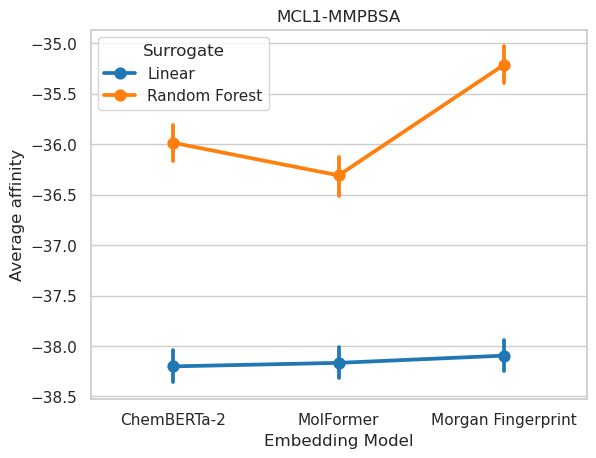

In [6]:
g = sns.pointplot(
    data,
    y="affinity",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    order=sorted(data["Embedding Model"].unique())
)
g.set_ylabel("Average affinity")
g.set_title(TITLE)

In [7]:
data.groupby(["Embedding Model", "Surrogate"])["is_top_k"].agg(lambda x: x.sum() / K)

Embedding Model     Surrogate    
ChemBERTa-2         Linear           0.568067
                    Random Forest    0.428571
MolFormer           Linear           0.556303
                    Random Forest    0.489076
Morgan Fingerprint  Linear           0.482353
                    Random Forest    0.368067
Name: is_top_k, dtype: float64

Text(0.5, 1.0, 'MCL1-MMPBSA')

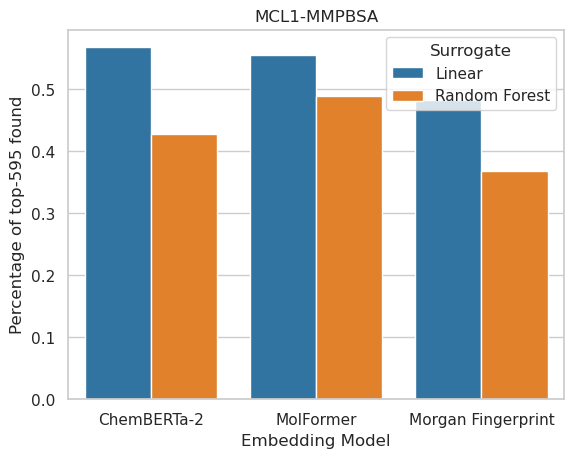

In [8]:
g = sns.barplot(
    data,
    y="is_top_k",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    errorbar=None,
    estimator = lambda x: x.sum() / K,
    order=sorted(data["Embedding Model"].unique()),
    dodge=True
)
g.set_ylabel(f"Percentage of top-{K} found")
g.set_title(TITLE)

Text(0.5, 0.98, 'MCL1-MMPBSA')

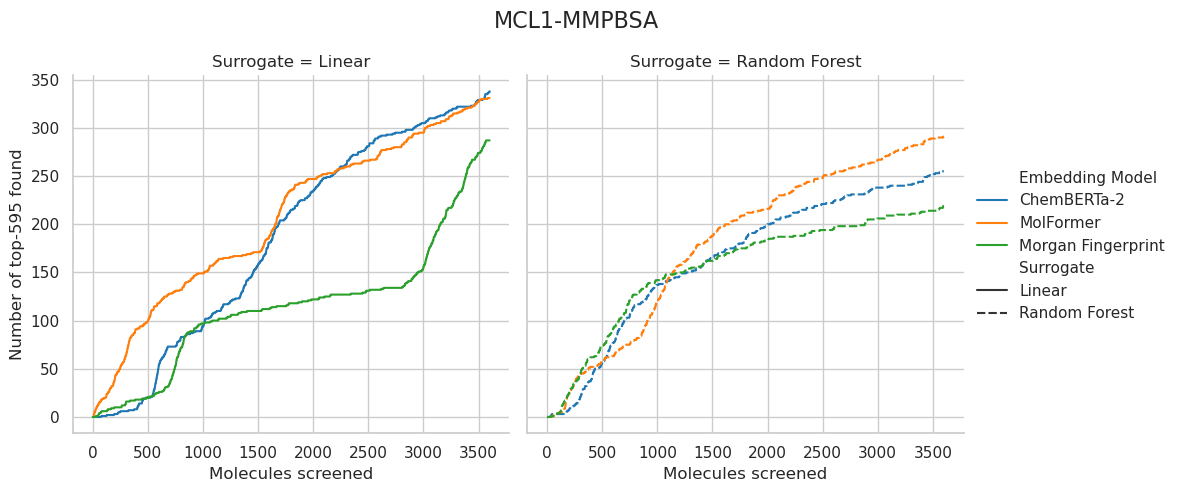

In [9]:
import matplotlib.pyplot as plt

use_markers = data["Iteration"].max() < 10

g = sns.relplot(
    data,
    y="is_top_k_cum",
    x="Iteration",
    hue="Embedding Model",
    col="Surrogate",
    col_order=["Linear", "Random Forest"],
    errorbar=None,
    kind="line",
    style="Surrogate",
    style_order=["Linear", "Random Forest"],
    markers="o" if use_markers else None,
    markeredgecolor="k",
    hue_order=sorted(data["Embedding Model"].unique())
)


g.set_xlabels("Molecules screened")
g.set_ylabels(f"Number of top-{K} found")
if use_markers:
    labels = [0] + sorted(data["Iteration"].unique() * len(top_k))
    def set_ticks(**kwargs):
        plt.gca().set_xticklabels(labels)

    g.map(set_ticks)
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle(TITLE, fontsize=16)
